In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec

import os

import seaborn as sns


In [3]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'



## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'



# Load peak annotations [including peak AUC score from Genrich peaks]
annotation_dir = os.path.join(entropy_dir, 'annotation')
peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_peaks.bed'),      sep='\t')
entropy_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_entropy_peaks.bed'), sep='\t')
lost_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_lost_peaks.bed'), sep='\t')
newly_discovered_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_newly_discovered_peaks.bed'),  sep='\t')


In [4]:

## calcualte peak size
newly_discovered_peaks_annot['peak_size'] = newly_discovered_peaks_annot['End'] - newly_discovered_peaks_annot['Start']
lost_peaks_annot['peak_size'] = lost_peaks_annot['End'] - lost_peaks_annot['Start']

peaks_annot['peak_size'] = peaks_annot['End'] - peaks_annot['Start']
entropy_peaks_annot['peak_size'] = entropy_peaks_annot['End'] - entropy_peaks_annot['Start']

## Peak AUC score 

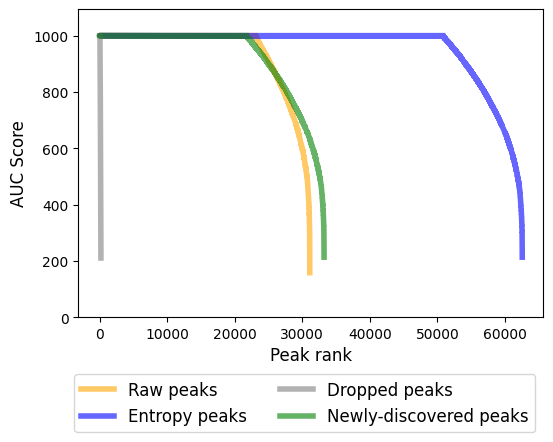

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='orange', alpha=0.6, label='Raw peaks', lw=4)
ax.plot(entropy_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='blue', alpha=0.6, label='Entropy peaks', lw=4)
ax.plot(lost_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='gray', alpha=0.6, label='Dropped peaks', lw=4)
ax.plot(newly_discovered_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='green', alpha=0.6, label='Newly-discovered peaks', lw=4)
# ax.set_title('Peak Score Comparison', fontsize=12)
ax.set_xlabel('Peak rank', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_ylim(0, ax.get_ylim()[1]*1.05)
ax.legend( loc='lower right', bbox_to_anchor=(1, -0.4), fontsize=12, ncol=2)

--- 	 Raw
peaks , Entropy
Peaks , Dropped
Peaks Newly-discovered
Peaks
Mean [np.float64(943.8465419719759), np.float64(959.015280108687), np.float64(762.5192307692307), np.float64(924.6667769987663)]
Median [np.float64(1000.0), np.float64(1000.0), np.float64(823.5), np.float64(1000.0)]


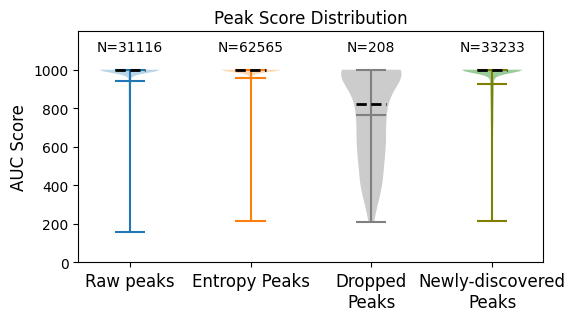

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
x_positions = range(4)
width = 0.5 




v1 = ax.violinplot( peaks_annot['Peak Score'], positions=[0], widths=width, vert=True, showmedians=True, showmeans=True,)
v2 = ax.violinplot( entropy_peaks_annot['Peak Score'], positions=[1], widths=width, vert=True, showmedians=True, showmeans=True,)
v3 = ax.violinplot( lost_peaks_annot['Peak Score'], positions=[2], widths=width, vert=True, showmedians=True, showmeans=True,)
v4 = ax.violinplot( newly_discovered_peaks_annot['Peak Score'], positions=[3], widths=width, vert=True, showmedians=True, showmeans=True,)


ax.text(0, ax.get_ylim()[1]*1.05, f'N={len(peaks_annot)}', ha='center', fontsize=10)
ax.text(1, ax.get_ylim()[1]*1.05, f'N={len(entropy_peaks_annot)}', ha='center', fontsize=10)
ax.text(2, ax.get_ylim()[1]*1.05, f'N={len(lost_peaks_annot)}', ha='center', fontsize=10)
ax.text(3, ax.get_ylim()[1]*1.05, f'N={len(newly_discovered_peaks_annot)}', ha='center', fontsize=10)


ax.set_ylim(0, ax.get_ylim()[1]*1.15)
ax.set_xticks(x_positions, [ 'Raw peaks', 'Entropy Peaks', 'Dropped\nPeaks', 'Newly-discovered\nPeaks', ], fontsize=12)  
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('Peak Score Distribution', fontsize=12)


for body in v3['bodies']:
    body.set_alpha(0.4)
    body.set_facecolor('grey')

for partname in ['cbars', 'cmins', 'cmaxes', 'cmeans']:
    v3[partname].set_edgecolor('grey')

for body in v4['bodies']:
    body.set_alpha(0.4)
    body.set_facecolor('green')
    
for partname in ['cbars', 'cmins', 'cmaxes', 'cmeans']:
    v4[partname].set_edgecolor('olive')

for v in [v1, v2, v3, v4]:
    v['cmedians'].set_linewidth(2)
    v['cmedians'].set_linestyle('--')
    v['cmedians'].set_color('black')




auc_score = [
             peaks_annot['Peak Score'], 
             entropy_peaks_annot['Peak Score'], 
             lost_peaks_annot['Peak Score'], 
             newly_discovered_peaks_annot['Peak Score'], 
             ]
mean_score = [np.mean(a) for a in auc_score]
median_score = [np.median(a) for a in auc_score]
print ('--- \t Raw\npeaks , Entropy\nPeaks , Dropped\nPeaks', 'Newly-discovered\nPeaks')
print (f'Mean {mean_score}')
print (f'Median {median_score}')


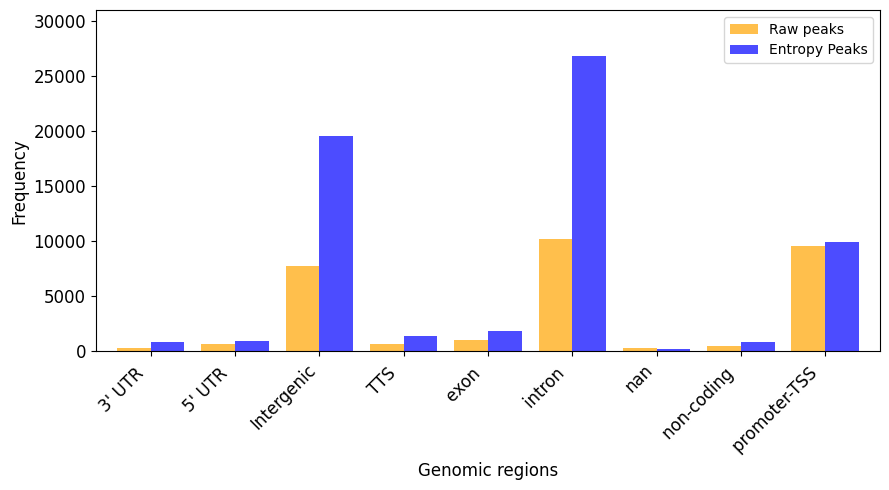

In [7]:
def simplify_annotation(annot_df, inplace=False):
    """
    Simplify the Annotation column.
    """
    if not inplace:
        annot_df = annot_df.copy()
        annot_df['simple_annotation'] = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        return annot_df
    else:
        # in place change of the  DataFrame
        annot_df['simple_annotation'] = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        
simplify_annotation(peaks_annot, inplace=True)
simplify_annotation(entropy_peaks_annot, inplace=True)
simplify_annotation(lost_peaks_annot, inplace=True)
simplify_annotation(newly_discovered_peaks_annot, inplace=True)

        
standard_peak_freq = peaks_annot['simple_annotation'].value_counts()
entropy_peak_freq = entropy_peaks_annot['simple_annotation'].value_counts()
newly_discovered_peak_freq = newly_discovered_peaks_annot['simple_annotation'].value_counts()
lost_standard_peak_freq = lost_peaks_annot['simple_annotation'].value_counts()

freq_df = pd.DataFrame({
    'Raw peaks': standard_peak_freq,
    'Entropy Peaks': entropy_peak_freq
}).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
freq_df.plot(kind='bar', width=0.8, alpha=0.7, ax=ax, color=['orange', 'blue'], fontsize=12)

# for i, tick in enumerate(ax.get_xticklabels()):
#     region_type = tick.get_text()
#     count = entropy_peak_freq[region_type]
#     ax.text(i + .22, count +400 , f'{count}', ha='center', fontsize=12)

# for i, tick in enumerate(ax.get_xticklabels()):
#     region_type = tick.get_text()
#     count = standard_peak_freq[region_type]
#     ax.text(i - .31, count + 300 , f'  {count}' if count < 1000 else f'{count}', ha='center', fontsize=12)
  

# ax.set_title('Peak Annotation Frequency Comparison', fontsize=12)
ax.set_ylim( 0, ax.get_ylim()[1]*1.1)
ax.set_xlabel('Genomic regions', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
fig.tight_layout()

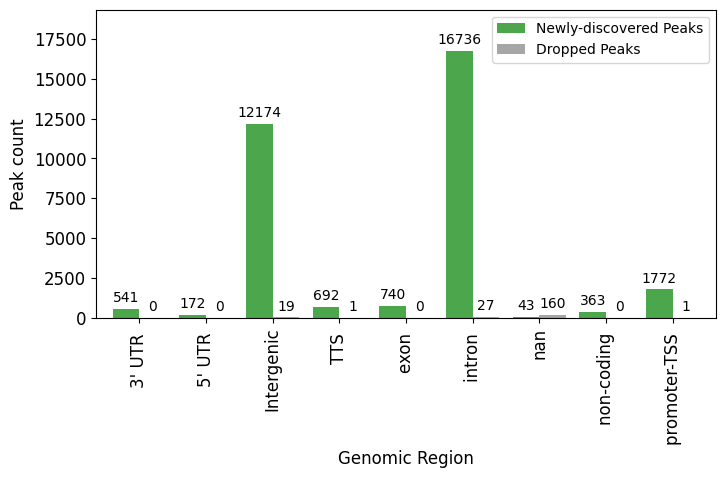

In [8]:
color_map = {'intron ': 'blue', 'promoter-TSS ': 'orange', 'Intergenic': 'green', 'exon ': 'red',
                "5' UTR ": 'purple', 'TTS ': 'brown', 'non-coding ': 'pink', "3' UTR ": 'slateblue', 'nan': 'grey'}
index_map = {'intron ': 0, 'promoter-TSS ': 1, 'Intergenic': 2, 'exon ': 3,
                "5' UTR ": 4, 'TTS ': 5, 'non-coding ': 6, "3' UTR ": 7, 'nan': 8}

width = 0.3  # the width of the bars
fig, ax = plt.subplots( nrows=1, ncols=1, figsize=(8,4))

a=newly_discovered_peak_freq.to_frame().merge(
    lost_standard_peak_freq.to_frame(), left_index=True, right_index=True, how='outer', suffixes=('_newly_discovered', '_dropped')).fillna(0)
a.rename(columns={'count_newly_discovered': 'Newly-discovered Peaks', 'count_dropped': 'Dropped Peaks'}, inplace=True)
a.plot(kind='bar', width=0.8, alpha=0.7, ax=ax, color=['green', 'grey'], fontsize=12)
ax.set_ylim( 0, ax.get_ylim()[1]*1.1)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

    
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Peak count', fontsize=12)
ax.set_xlabel('Genomic Region', fontsize=12) 
# ax.set_xticks([0, 1], ['Newly-discovered Peaks', 'Lost Peaks'])
ax.legend(loc='upper right', ncols=1, bbox_to_anchor=(1, 1))



plt.show()

/tmp/ipykernel_3081058/2099982464.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=lost_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[1],


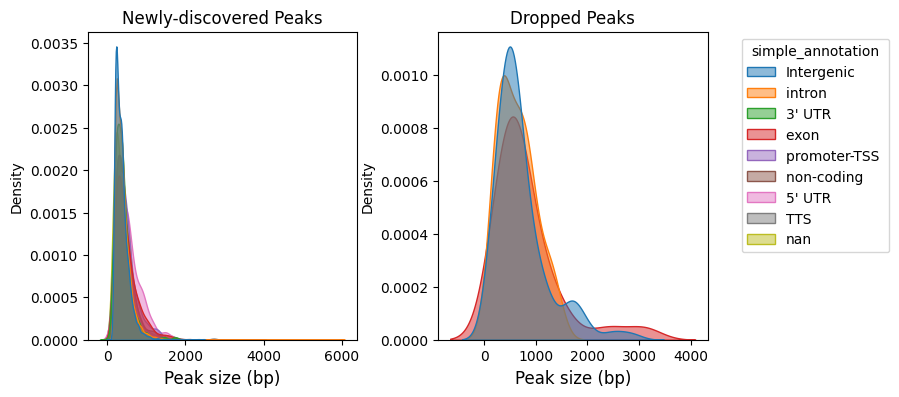

In [9]:
color_map = {'intron ': 'blue', 'promoter-TSS ': 'orange', 'Intergenic': 'green', 'exon ': 'red',
                "5' UTR ": 'purple', 'TTS ': 'brown', 'non-coding ': 'pink', "3' UTR ": 'slateblue', 'nan': 'grey'}
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

sns.kdeplot(data=newly_discovered_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[0], 
            common_norm=False, alpha=0.5, color=color_map)
sns.kdeplot(data=lost_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[1], 
            common_norm=False, alpha=0.5, color=color_map)

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)


ax[1].legend_.remove()
sns.move_legend(ax[0], "upper right", bbox_to_anchor=(3, 1))

fig.subplots_adjust(wspace=0.3)

-------------- 	 Raw peaks , Entropy peaks , Newly-discovered peaks , Dropped peaks
Median peak size: ['534.5         ', '514.0         ', '347.0         ', '570.0         ']
Mean peak size: [np.float64(699.3211852423191), np.float64(735.485638935507), np.float64(396.6249811933921), np.float64(718.8317307692307)]


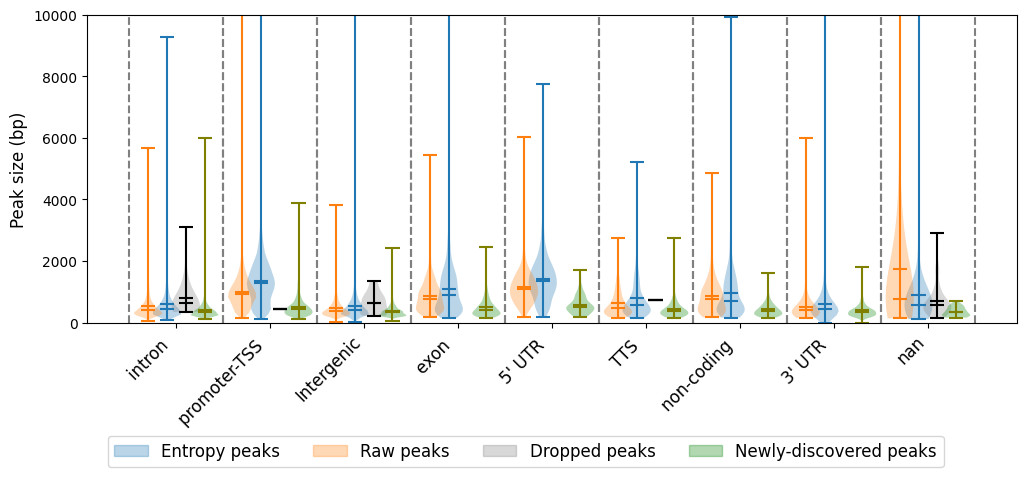

In [32]:
from matplotlib.pylab import size


position_map = {'intron ': 0, 'promoter-TSS ': 1, 'Intergenic': 2, 'exon ': 3,
                "5' UTR ": 4, 'TTS ': 5, 'non-coding ': 6, "3' UTR ": 7, 'nan': 8}

position_map_reversed = {v: k for k, v in position_map.items()}


def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    

x_positions = range(len(position_map)) 
width = 0.3  # the width of the bars
labels = []

fig, ax = plt.subplots( figsize=(12, 4))

standard_type = peaks_annot['simple_annotation'].unique()
entropy_type = entropy_peaks_annot['simple_annotation'].unique()
newly_discovered_type = newly_discovered_peaks_annot['simple_annotation'].unique()
lost_type = lost_peaks_annot['simple_annotation'].unique()

standard_peak_size = [ peaks_annot.loc[peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in standard_type ]

entropy_peak_size = [ entropy_peaks_annot.loc[entropy_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in entropy_type ]
newly_discovered_peak_size = [ newly_discovered_peaks_annot.loc[newly_discovered_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in newly_discovered_type     ]  
lost_peak_size = [ lost_peaks_annot.loc[lost_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in lost_type ]


v2 =ax.violinplot( entropy_peak_size, 
              positions=[position_map[genome_type] - 0.1 for genome_type in entropy_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
add_label(v2, 'Entropy peaks')

v1 = ax.violinplot( standard_peak_size, 
              positions=[position_map[genome_type] - 0.3 for genome_type in standard_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
add_label(v1, 'Raw peaks')


v3 = ax.violinplot( lost_peak_size, 
              positions=[position_map[genome_type] + 0.1 for genome_type in lost_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
# change color 
for body in v3['bodies']:
    body.set_facecolor( 'grey'   )
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    v3[partname].set_edgecolor('black')
add_label(v3, 'Dropped peaks')


v4 =ax.violinplot( newly_discovered_peak_size, 
              positions=[position_map[genome_type] + 0.3 for genome_type in newly_discovered_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
# change color
for body in v4['bodies']:
    body.set_facecolor('green')
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    v4[partname].set_edgecolor('olive')

add_label(v4, 'Newly-discovered peaks')


## Add vertical line to separate each group
for x in x_positions:
    ax.vlines(x + 0.5 , ymin=0, ymax=20000, colors='grey', linestyles='--')
    ax.vlines(x - 0.5 , ymin=0, ymax=20000, colors='grey', linestyles='--')


ax.set_xticks(x_positions)
ax.set_xticklabels([position_map_reversed[i] for i in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylim(0, 10000)
ax.set_ylabel('Peak size (bp)', fontsize=12)
plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(0.93, -0.34), ncol=4, fontsize=12)

median_peak_size = [np.median(peaks_annot['peak_size']), np.median(entropy_peaks_annot['peak_size']),
                    np.median(newly_discovered_peaks_annot['peak_size']), np.median(lost_peaks_annot['peak_size'])]
mean_peak_size = [np.mean(peaks_annot['peak_size']), np.mean(entropy_peaks_annot['peak_size']),
                    np.mean(newly_discovered_peaks_annot['peak_size']), np.mean(lost_peaks_annot['peak_size'])]
print(f'-------------- \t Raw peaks , Entropy peaks , Newly-discovered peaks , Dropped peaks')
print(f'Median peak size: {[str(size) + "         " for size in median_peak_size]}') # show with 4 decimal places
print(f'Mean peak size: {mean_peak_size}')




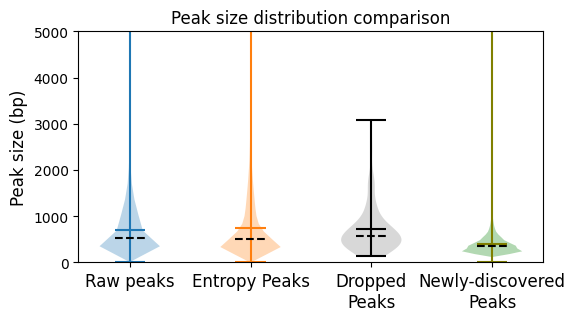

In [11]:
fig, ax = plt.subplots( nrows=1, ncols=1, figsize=(6,3))
width = 0.5
v1 = ax.violinplot( peaks_annot['peak_size'], positions=[0], widths=width, vert=True, showmedians=True, showmeans=True,)
v2 = ax.violinplot( entropy_peaks_annot['peak_size'], positions=[1], widths=width, vert=True, showmedians=True, showmeans=True,)
v3 = ax.violinplot( lost_peaks_annot['peak_size'], positions=[2], widths=width, vert=True, showmedians=True, showmeans=True,)
v4 = ax.violinplot( newly_discovered_peaks_annot['peak_size'], positions=[3], widths=width, vert=True, showmedians=True, showmeans=True,)

ax.set_xticks([0, 1, 2, 3], ['Raw peaks', 'Entropy Peaks', 'Dropped\nPeaks', 'Newly-discovered\nPeaks'], fontsize=12)
ax.set_ylabel('Peak size (bp)', fontsize=12)
ax.set_title('Peak size distribution comparison', fontsize=12)
ax.set_ylim(0, 5000)

for v in (v1, v2, v3, v4):
    v['cmedians'].set_linestyle('--')
    v['cmedians'].set_color('black')

for body in v3['bodies']:
    body.set_facecolor('grey')
    
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    v3[partname].set_edgecolor('black')
    
for body in v4['bodies']:
    body.set_facecolor('green')
for partname in ('cbars','cmins','cmaxes','cmeans'):
    v4[partname].set_edgecolor('olive')


In [12]:
newly_discovered_peaks_annot

,PeakID (cmd=annotatePeaks.pl /home/syyang/adipose_ln/atac/res/VIB_10xmultiome_2_WS3000F/peaks_comparison/newly_discovered_peaks.bed hg38 -annStats /home/syyang/adipose_ln/atac/res/VIB_10xmultiome_2_WS3000F/annotation/annStats_newly_discovered_peaks.txt),Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,...,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type,peak_size,simple_annotation
0,peak_38708,chr20,57431008,57431609,+,1000,NaN,Intergenic,AluSx|SINE|Alu,-38252.0,...,100291105.0,NaN,NR_149006,NaN,RBM38-AS1,-,RBM38 antisense RNA 1,ncRNA,601,Intergenic
1,peak_9910,chr11,10612309,10612762,+,1000,NaN,"intron (NM_001100163, intron 10 of 20)",L1M7|LINE|L1,39743.0,...,10335.0,NaN,NM_130385,ENSG00000072952,IRAG1,IRAG|JAW1L|MRVI1,"inositol 1,4,5-triphosphate receptor associated 1",protein-coding,453,intron
2,peak_49804,chr5,168219724,168220077,+,1000,NaN,"intron (NM_001080428, intron 19 of 24)","intron (NM_001080428, intron 19 of 24)",12472.0,...,101927862.0,NaN,NR_109894,ENSG00000253978,TENM2-AS1,CTB-178M22.2,TENM2 antisense RNA 2,ncRNA,353,intron
3,peak_37788,chr20,31684709,31685022,+,1000,NaN,"intron (NR_134257, intron 1 of 2)","intron (NR_134257, intron 1 of 2)",-36642.0,...,103021294.0,NaN,NR_131907,ENSG00000281376,ABALON,INXS,apoptotic BCL2L1-antisense long non-coding RNA,ncRNA,313,intron
4,peak_26196,chr17,48804937,48805267,+,1000,NaN,"intron (NM_001366314, intron 1 of 13)","intron (NM_001366314, intron 1 of 13)",-10778.0,...,284076.0,NaN,NM_173623,ENSG00000170703,TTLL6,TTL.6,tubulin tyrosine ligase like 6,protein-coding,330,intron
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33228,peak_19031,chr14,101814913,101815768,+,237,NaN,"intron (NM_178587, intron 1 of 11)","intron (NM_178587, intron 1 of 11)",5477.0,...,5527.0,NaN,NM_002719,ENSG00000078304,PPP2R5C,B56G|B56gamma|PR61G,protein phosphatase 2 regulatory subunit B'gamma,protein-coding,855,intron
33229,peak_6550,chr10,3774265,3775139,+,235,NaN,Intergenic,Intergenic,10507.0,...,1316.0,NaN,NM_001300,ENSG00000067082,KLF6,BCD1|CBA1|COPEB|CPBP|GBF|PAC1|ST12|ZF9,KLF transcription factor 6,protein-coding,874,Intergenic
33230,peak_51367,chr6,31969375,31970361,+,222,NaN,TTS (NM_006929).3,TTS (NM_006929).3,-1307.0,...,8859.0,NaN,NM_004197,ENSG00000204344,STK19,D6S60|D6S60E|G11|HLA-RP1|RP1,serine/threonine kinase 19,protein-coding,986,TTS
33231,peak_6764,chr10,11168339,11169378,+,222,NaN,"intron (NM_001326346, intron 2 of 11)","intron (NM_001326346, intron 2 of 11)",3828.0,...,10659.0,NaN,NM_006561,ENSG00000048740,CELF2,BRUNOL3|CELF-2|CUG-BP2|CUGBP2|DEE97|ETR-3|ETR3...,CUGBP Elav-like family member 2,protein-coding,1039,intron


# Check cCRE annotations

In [13]:
cCRE_subdir=os.path.join(entropy_dir, 'cCRE_annotation')
cCRE_newly_discovered_peaks_file = os.path.join(cCRE_subdir, 'cCRE_annot_newly_discovered_peaks.bed')
cCRE_lost_peaks_file = os.path.join(cCRE_subdir, 'cCRE_annot_lost_peaks.bed')

cCRE_newly_discovered_peaks = pd.read_csv(cCRE_newly_discovered_peaks_file, sep='\t', header=None)
cCRE_lost_peaks = pd.read_csv(cCRE_lost_peaks_file, sep='\t', header=None)

columns = ['chrom', 'chromStart', 'chromEnd', 'name', 'peak_auc_score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak', 
           'cCREs_chrom', 'cCREs_start', 'cCREs_end', 'cCREs_an1', 'cCREs_an2', 'encode_label', 'overlap_bp']

cCRE_lost_peaks.columns = columns
cCRE_newly_discovered_peaks.columns = columns

cCRE_lost_peaks.shape, cCRE_newly_discovered_peaks.shape,

((208, 17), (46718, 17))

In [14]:
cCRE_newly_discovered_peaks.head(2)

,chrom,chromStart,chromEnd,name,peak_auc_score,strand,signalValue,pValue,qValue,peak,cCREs_chrom,cCREs_start,cCREs_end,cCREs_an1,cCREs_an2,encode_label,overlap_bp
0,chr1,842065,842407,peak_35,1000,.,516.327820,4.445836,-1,122,chr1,842235,842387,EH38D4327628,EH38E2776568,dELS,152
1,chr1,857965,858226,peak_36,1000,.,311.858093,4.013170,-1,177,.,-1,-1,.,.,.,0


In [15]:
cCRE_lost_peaks.head(6)

,chrom,chromStart,chromEnd,name,peak_auc_score,strand,signalValue,pValue,qValue,peak,cCREs_chrom,cCREs_start,cCREs_end,cCREs_an1,cCREs_an2,encode_label,overlap_bp
0,chr1,2440357,2440672,peak_122,1000,.,331.285126,3.861190,-1,92,.,-1,-1,.,.,.,0
1,chr1,2652157,2652543,peak_130,1000,.,651.515869,4.448456,-1,293,.,-1,-1,.,.,.,0
2,chr1,2657456,2660546,peak_132,840,.,2594.274658,4.141789,-1,2244,.,-1,-1,.,.,.,0
3,chr1,2660670,2663058,peak_133,576,.,1375.831665,3.323993,-1,618,.,-1,-1,.,.,.,0
4,chr1,2663175,2663930,peak_134,342,.,257.992554,3.048749,-1,63,.,-1,-1,.,.,.,0
5,chr1,2664230,2665587,peak_135,371,.,503.672852,2.914509,-1,679,.,-1,-1,.,.,.,0


In [16]:
# total lost peaks that cover CREs 
len(cCRE_lost_peaks.loc[cCRE_lost_peaks['overlap_bp'] > 0 ]['name'].unique()) 

1

In [17]:
# Total CREs newly-discovered peaks cover
cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0 ].shape  # total cCREs are covered 


(45075, 17)

In [18]:
# total newly-discovered peaks that cover CREs 
len(cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0 ]['name'].unique()) 

31590

# Vis cCREs

In [19]:
cCRE_newly_discovered_peaks['peak_size'] = cCRE_newly_discovered_peaks['chromEnd'] - cCRE_newly_discovered_peaks['chromStart']
cCRE_newly_discovered_peaks['cCREs_size'] = cCRE_newly_discovered_peaks['cCREs_end'] - cCRE_newly_discovered_peaks['cCREs_start']
cCRE_newly_discovered_peaks['overlap_cCREs'] = cCRE_newly_discovered_peaks['overlap_bp'] > 0 



cCRE_lost_peaks['peak_size'] = cCRE_lost_peaks['chromEnd'] - cCRE_lost_peaks['chromStart']
cCRE_lost_peaks['cCREs_size'] = cCRE_lost_peaks['cCREs_end'] - cCRE_lost_peaks['cCREs_start']
cCRE_lost_peaks['overlap_cCREs'] = cCRE_lost_peaks['overlap_bp'] > 0 



/tmp/ipykernel_3081058/2922546369.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  g1 = sns.kdeplot(data=cCRE_lost_peaks, x='peak_size', hue='covered_cCREs_category', fill=True, ax=ax[1],


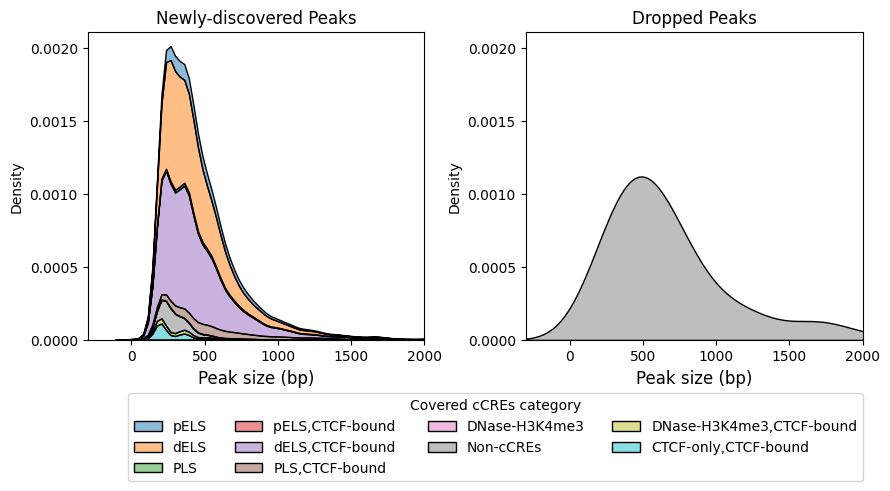

In [ ]:
cCRE_newly_discovered_peaks['covered_cCREs_category'] = cCRE_newly_discovered_peaks['encode_label'] 
cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['encode_label'] == '.', 'covered_cCREs_category'] = 'Non-cCREs'

cCRE_lost_peaks['covered_cCREs_category'] = cCRE_lost_peaks['encode_label']
cCRE_lost_peaks.loc[cCRE_lost_peaks['encode_label'] == '.', 'covered_cCREs_category'] = 'Non-cCREs'



hue_color = ['pELS', 'dELS', 'PLS', 
             'pELS,CTCF-bound ',  'dELS,CTCF-bound', "PLS,CTCF-bound", 
             'DNase-H3K4me3', 'Non-cCREs',  "DNase-H3K4me3,CTCF-bound", 'CTCF-only,CTCF-bound',]
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

g0 = sns.kdeplot(data=cCRE_newly_discovered_peaks, x='peak_size', hue='covered_cCREs_category', fill=True, ax=ax[0], 
            common_norm=True, alpha=0.5, hue_order=hue_color, multiple='stack')
g1 = sns.kdeplot(data=cCRE_lost_peaks, x='peak_size', hue='covered_cCREs_category', fill=True, ax=ax[1], 
            common_norm=True, alpha=0.5, hue_order=hue_color, multiple='stack')

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)

ax[0].set_xlim(-300, 2000)
ax[1].set_xlim(-300, 2000)
ax[0].set_xticks(np.arange(0, 2001, 500))
ax[1].set_xticks(np.arange(0, 2001, 500))
ax[0].set_ylim(0, ax[0].get_ylim()[1])
ax[1].set_ylim(0, ax[0].get_ylim()[1])
ax[0].set_yticks(np.arange(0, ax[0].get_ylim()[1], 0.0005))
ax[1].set_yticks(np.arange(0, ax[0].get_ylim()[1] , 0.0005))


ax[1].legend_.remove()
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(0.1, -.15), title='Covered cCREs category', fontsize=10, ncol=4)


fig.subplots_adjust(wspace=0.3)

/tmp/ipykernel_3081058/731697661.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  g1 = sns.kdeplot(data=cCRE_lost_peaks, x='peak_size', hue='overlap_cCREs', fill=True, ax=ax[1],


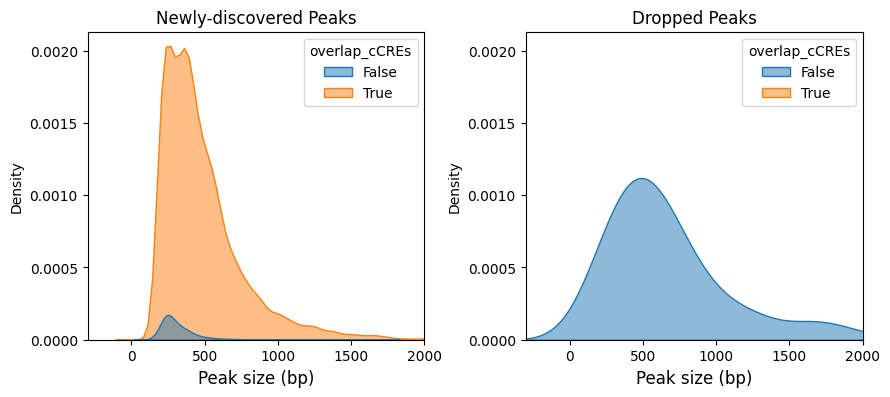

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

g0 = sns.kdeplot(data=cCRE_newly_discovered_peaks, x='peak_size', hue='overlap_cCREs', fill=True, ax=ax[0], 
            common_norm=True, alpha=0.5, color=['green', 'grey'])
g1 = sns.kdeplot(data=cCRE_lost_peaks, x='peak_size', hue='overlap_cCREs', fill=True, ax=ax[1], 
            common_norm=True, alpha=0.5, color=['green', 'grey'])

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)

ax[0].set_xlim(-300, 2000)
ax[1].set_xlim(-300, 2000)
ax[0].set_xticks(np.arange(0, 2001, 500))
ax[1].set_xticks(np.arange(0, 2001, 500))
ax[0].set_ylim(0, ax[0].get_ylim()[1])
ax[1].set_ylim(0, ax[0].get_ylim()[1])
ax[0].set_yticks(np.arange(0, ax[0].get_ylim()[1], 0.0005))
ax[1].set_yticks(np.arange(0, ax[0].get_ylim()[1] , 0.0005))


fig.subplots_adjust(wspace=0.3)

/tmp/ipykernel_3081058/3597221937.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_3081058/3597221937.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)


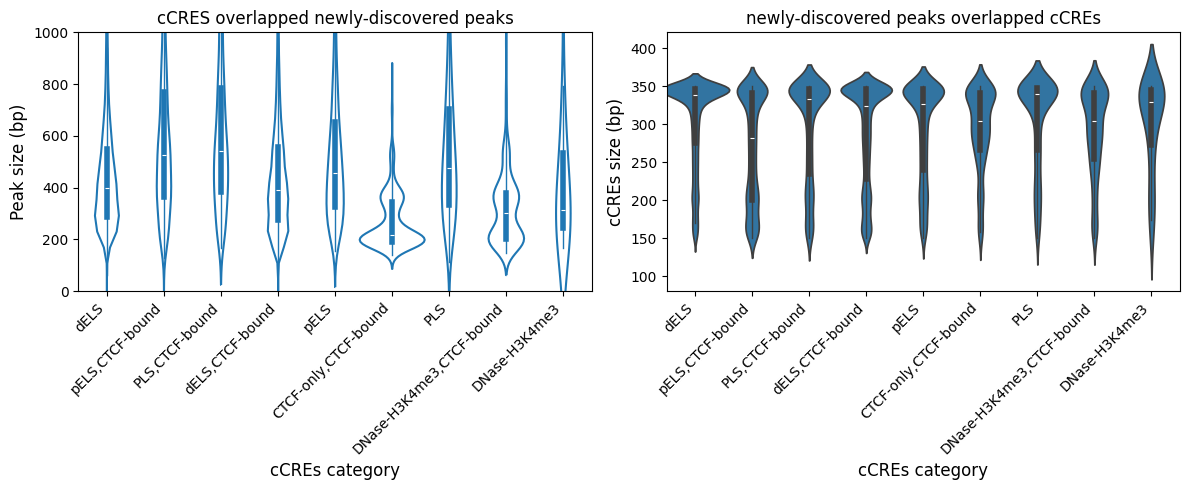

In [25]:


fig, ax = plt.subplots( 1, 2, figsize=( 12, 5))


sns.violinplot(data=cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0],
            y='peak_size', x='encode_label',  width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            fill=False, gap=.05, ax=ax[0])

ax[0].x_ticklabels = ax[0].get_xticklabels()
ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[0].set_title('cCRES overlapped newly-discovered peaks', fontsize=12)
ax[0].set_xlabel('cCREs category', fontsize=12)
ax[0].set_ylabel('Peak size (bp)', fontsize=12)
ax[0].set_ylim(0, 1000)
# sns.move_legend(ax[0], "upper left", bbox_to_anchor=(1.03, 1))

sns.violinplot(data=cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0], 
            y='cCREs_size', x='encode_label', width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            ax=ax[1])


ax[1].x_ticklabels = ax[1].get_xticklabels()
ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[1].set_title('newly-discovered peaks overlapped cCREs', fontsize=12)
ax[1].set_xlabel('cCREs category', fontsize=12)
ax[1].set_ylabel('cCREs size (bp)', fontsize=12)


plt.tight_layout()


/tmp/ipykernel_3081058/3010609903.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_3081058/3010609903.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)


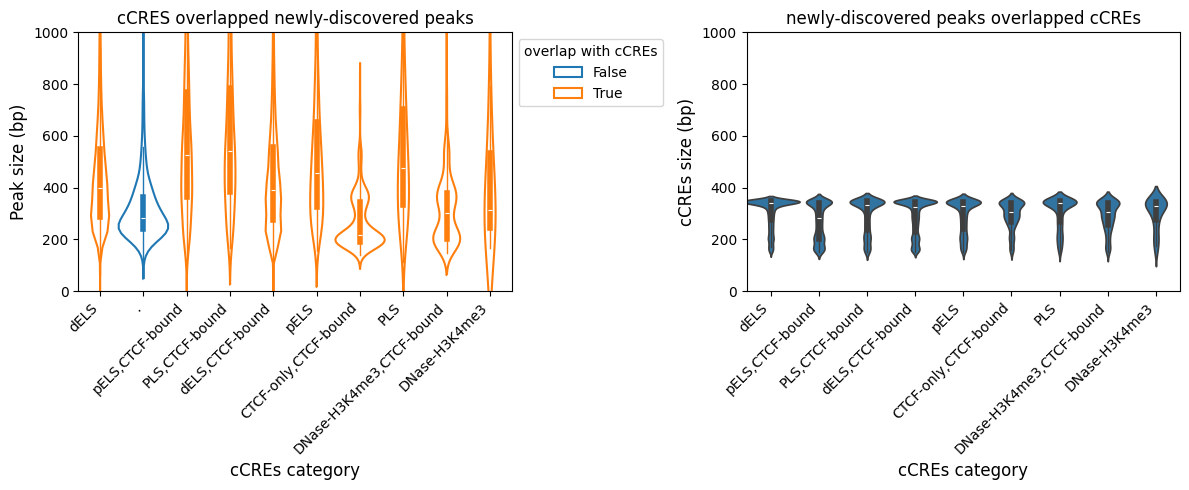

In [27]:

fig, ax = plt.subplots( 1, 2, figsize=( 12, 5))


sns.violinplot(data=cCRE_newly_discovered_peaks,
            y='peak_size', x='encode_label', hue='overlap_cCREs', width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            fill=False, gap=.05, ax=ax[0])

ax[0].x_ticklabels = ax[0].get_xticklabels()
ax[0].set_xticklabels(ax[0].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[0].set_title('cCRES overlapped newly-discovered peaks', fontsize=12)
ax[0].set_xlabel('cCREs category', fontsize=12)
ax[0].set_ylabel('Peak size (bp)', fontsize=12)
ax[0].legend(title='overlap with cCREs', loc='upper right', fontsize=10)
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(1, 1))

sns.violinplot(data=cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0], 
            y='cCREs_size', x='encode_label', width=1.2,  inner_kws=dict(box_width=4, whis_width=1),
            ax=ax[1])


ax[1].x_ticklabels = ax[1].get_xticklabels()
ax[1].set_xticklabels(ax[1].x_ticklabels, rotation=45, ha='right', fontsize=10)
ax[1].set_title('newly-discovered peaks overlapped cCREs', fontsize=12)
ax[1].set_xlabel('cCREs category', fontsize=12)
ax[1].set_ylabel('cCREs size (bp)', fontsize=12)


ax[0].set_ylim(0, 1000)
ax[1].set_ylim(0, 1000)

plt.tight_layout()